# TP 2 | Manipulation de signaux audio avec librosa

**Dataset :** [TP-02 Audio](https://www.kaggle.com/datasets/ouaraskhelilrafik/tp-02-audio) | extraits de 5 s au format `.ogg` issus d'ESC-10 (cris d'animaux, sons d'environnement), 40 fichiers par classe.

| # | Tâche |
|---|-------|
| 1 | Charger un fichier audio avec librosa |
| 2 | Afficher la taille du signal et sa durée |
| 3 | Tracer le waveform |
| 4 | Calculer et afficher le spectrogramme |
| 5 | Jouer le son dans Jupyter |
| 6 | Ajouter un bruit aléatoire et comparer au signal original |

## 0. Configuration

Dépendances : `librosa`, `numpy`, `matplotlib`, `kagglehub`.

In [1]:
from pathlib import Path

import kagglehub
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display

rng = np.random.default_rng(42)     # générateur aléatoire reproductible (question 6)
plt.rcParams["figure.dpi"] = 100
print(f"librosa {librosa.__version__}")

librosa 0.11.0


---
## 1. Charger un fichier audio avec librosa

In [2]:
path = kagglehub.dataset_download("ouaraskhelilrafik/tp-02-audio")
DATA_DIR = Path(path) / "Data" / "Data"

classes = sorted(d.name for d in DATA_DIR.iterdir() if d.is_dir())
for c in classes:
    print(f"{c:<15}: {len(list((DATA_DIR / c).glob('*.ogg')))} fichiers")

101 - Dog      : 40 fichiers
102 - Rooster  : 40 fichiers
103 - Pig      : 40 fichiers
104 - Cow      : 40 fichiers
105 - Frog     : 40 fichiers


`librosa.load` renvoie deux objets :
- `y` : le signal, un tableau NumPy 1D de nombres décimaux entre -1 et 1 (amplitude de l'onde sonore à chaque instant) ;
- `sr` : la **fréquence d'échantillonnage** (*sampling rate*), c'est-à-dire le nombre d'échantillons par seconde.

**Remarque :** par défaut, librosa rééchantillonne à 22 050 Hz et convertit en mono. `sr=None` conserve la fréquence d'origine du fichier.

In [3]:
AUDIO_FILE = DATA_DIR / "102 - Rooster" / "1-26806-A.ogg"

y, sr = librosa.load(AUDIO_FILE, sr=None)          # fréquence d'origine
y_22k, sr_22k = librosa.load(AUDIO_FILE)           # fréquence par défaut (22 050 Hz)

print(f"Fichier : {AUDIO_FILE.parent.name}/{AUDIO_FILE.name}")
print(f"sr=None    -> sr = {sr} Hz, {len(y)} échantillons")
print(f"par défaut -> sr = {sr_22k} Hz, {len(y_22k)} échantillons")

Fichier : 102 - Rooster/1-26806-A.ogg
sr=None    -> sr = 44100 Hz, 220544 échantillons
par défaut -> sr = 22050 Hz, 110272 échantillons


---
## 2. Taille du signal et durée

$$\text{durée (s)} = \frac{\text{nombre d'échantillons}}{\text{fréquence d'échantillonnage}}$$

In [4]:
n_samples = len(y)
duration = n_samples / sr

print(f"Forme du signal      : {y.shape}  (1D -> mono)")
print(f"Nombre d'échantillons: {n_samples:,}")
print(f"Fréquence            : {sr} Hz")
print(f"Durée                : {duration:.3f} s  (librosa.get_duration : {librosa.get_duration(y=y, sr=sr):.3f} s)")
print(f"Type                 : {y.dtype}")
print(f"Min / Max            : {y.min():.3f} / {y.max():.3f}")

Forme du signal      : (220544,)  (1D -> mono)
Nombre d'échantillons: 220,544
Fréquence            : 44100 Hz
Durée                : 5.001 s  (librosa.get_duration : 5.001 s)
Type                 : float32
Min / Max            : -0.929 / 0.965


Les deux versions chargées ont la **même durée** : rééchantillonner change le nombre d'échantillons par seconde, pas la longueur du son. 44 100 Hz permet de représenter des fréquences jusqu'à 22 050 Hz (fréquence de Nyquist = sr / 2), ce qui couvre l'audition humaine.

---
## 3. Tracer le waveform

Le waveform représente l'**amplitude** du signal en fonction du **temps**. Il montre quand le son est fort ou silencieux, mais pas quelles fréquences il contient.

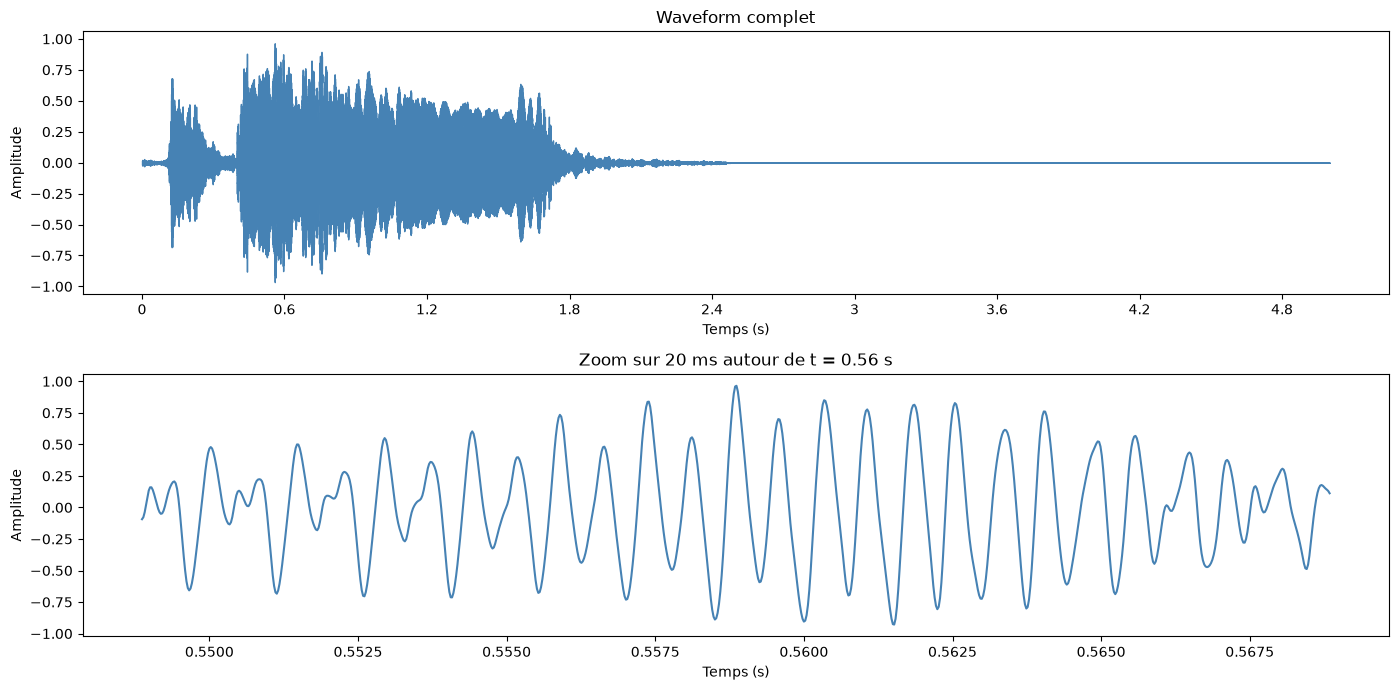

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

librosa.display.waveshow(y, sr=sr, ax=axes[0], color="steelblue")
axes[0].set_title("Waveform complet")
axes[0].set_xlabel("Temps (s)")
axes[0].set_ylabel("Amplitude")

# Zoom sur 20 ms autour du point le plus fort : on voit l'oscillation de l'onde
center = np.argmax(np.abs(y))
start, end = center - int(0.01 * sr), center + int(0.01 * sr)
t = np.arange(start, end) / sr
axes[1].plot(t, y[start:end], color="steelblue")
axes[1].set_title(f"Zoom sur 20 ms autour de t = {center / sr:.2f} s")
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

**Lecture :**
- Vue complète : un seul **chant de coq**, avec une courte attaque vers 0,15 s puis le chant principal de 0,4 à 1,8 s, qui s'éteint progressivement. À partir de 2,5 s, le signal est nul : **silence total** jusqu'à la fin des 5 s (les extraits ESC-10 sont complétés par du silence pour avoir tous la même durée).
- Zoom : à l'échelle de la milliseconde, le son est une **oscillation** rapide ; sa période est liée à la hauteur (fréquence) du son.

---
## 4. Spectrogramme

Le spectrogramme montre **quelles fréquences** sont présentes **à chaque instant**. On l'obtient par la **transformée de Fourier à court terme (STFT)** :
1. découper le signal en courtes fenêtres (`n_fft` échantillons), qui se chevauchent (décalage `hop_length`) ;
2. calculer le spectre (transformée de Fourier) de chaque fenêtre ;
3. convertir l'amplitude en **décibels** (échelle logarithmique, proche de la perception humaine).

Axes : temps en abscisse, fréquence en ordonnée, intensité en couleur.

In [6]:
N_FFT = 2048          # taille de fenêtre : 2048 / 44100 = 46 ms
HOP = 512             # décalage entre fenêtres : 512 / 44100 = 12 ms

D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP)          # matrice complexe (fréquences x fenêtres)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)     # module -> décibels (0 dB = maximum)

print(f"Forme du spectrogramme : {S_db.shape} -> {S_db.shape[0]} bandes de fréquence x {S_db.shape[1]} fenêtres temporelles")
print(f"Résolution fréquentielle : {sr / N_FFT:.1f} Hz | résolution temporelle : {HOP / sr * 1000:.1f} ms")

Forme du spectrogramme : (1025, 431) -> 1025 bandes de fréquence x 431 fenêtres temporelles
Résolution fréquentielle : 21.5 Hz | résolution temporelle : 11.6 ms


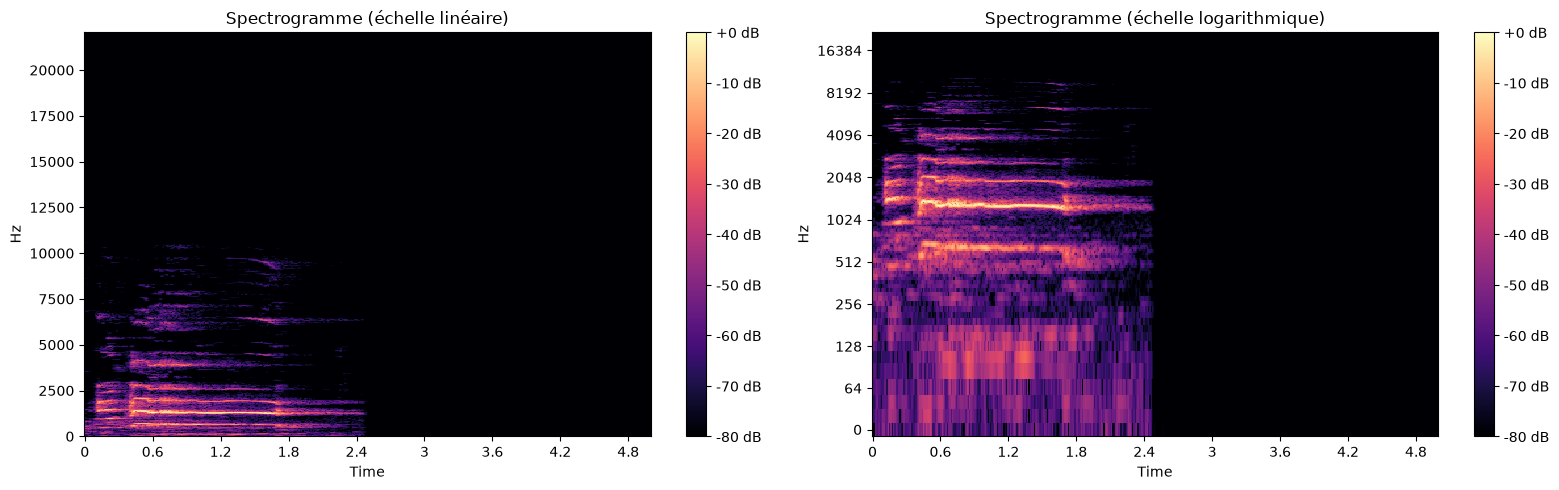

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP, x_axis="time", y_axis="linear", ax=axes[0])
axes[0].set_title("Spectrogramme (échelle linéaire)")
fig.colorbar(img, ax=axes[0], format="%+2.0f dB")

img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP, x_axis="time", y_axis="log", ax=axes[1])
axes[1].set_title("Spectrogramme (échelle logarithmique)")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

**Lecture :**
- Le chant apparaît comme une série de **bandes horizontales parallèles** : la **fréquence fondamentale** (vers 650 Hz) et ses **harmoniques**, des multiples de la fondamentale (vers 1,3 kHz, 2 kHz, 2,6 kHz...). L'harmonique vers 1,3 kHz est la plus intense. Leur forme suit la mélodie du cri.
- L'échelle **logarithmique** détaille mieux les basses fréquences, où se trouve l'essentiel de l'énergie ; c'est aussi plus proche de notre perception des hauteurs.
- L'énergie diffuse sous 200 Hz est un bruit de fond de l'enregistrement (vent, environnement).
- Au-delà de 2,5 s, le spectrogramme est entièrement noir : c'est le silence vu sur le waveform.

### Mel-spectrogramme

Variante utilisée en apprentissage automatique : les fréquences sont regroupées selon l'**échelle de Mel**, qui imite la sensibilité de l'oreille (fine dans les graves, grossière dans les aigus). Résultat plus compact : 128 bandes au lieu de 1025.

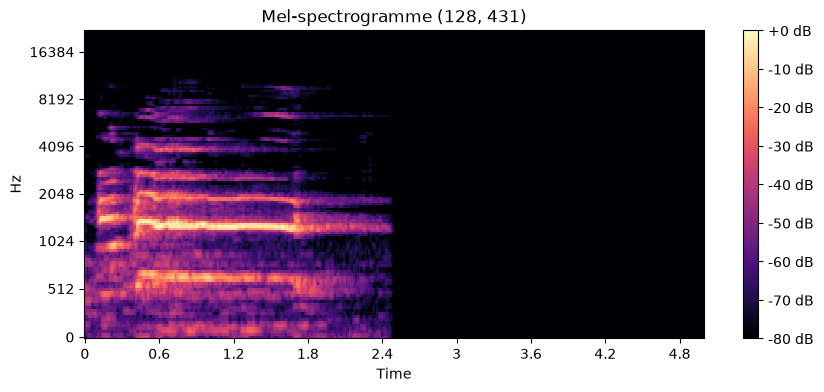

In [8]:
M = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=128)
M_db = librosa.power_to_db(M, ref=np.max)

fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(M_db, sr=sr, hop_length=HOP, x_axis="time", y_axis="mel", ax=ax)
ax.set_title(f"Mel-spectrogramme {M_db.shape}")
fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.show()

### Comparaison entre classes

Un exemple par classe : chaque animal a une « signature » visuelle différente. C'est pourquoi les spectrogrammes servent d'entrée aux modèles de classification audio.

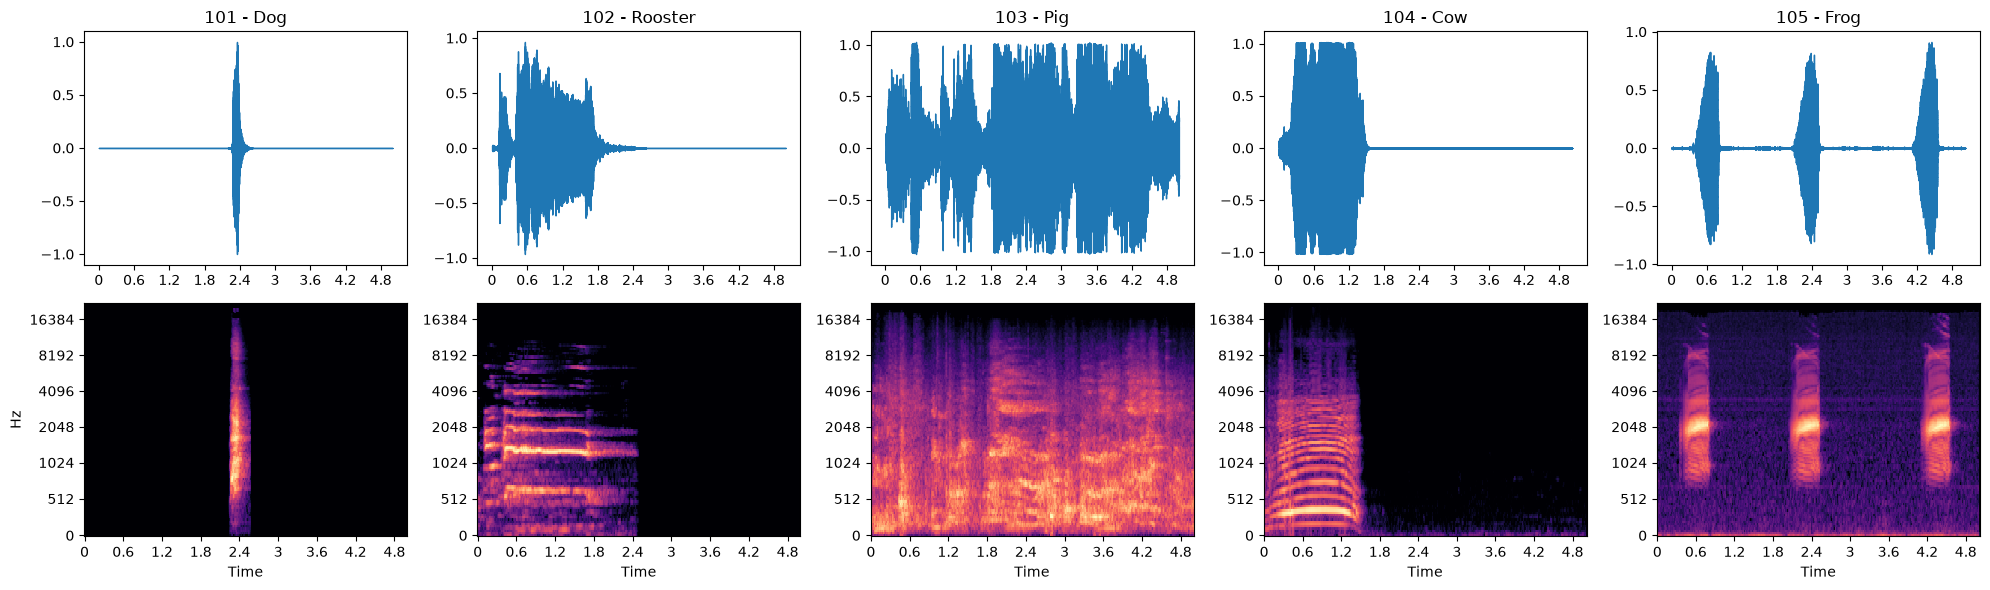

In [9]:
fig, axes = plt.subplots(2, len(classes), figsize=(4 * len(classes), 6))
for j, c in enumerate(classes):
    f = sorted((DATA_DIR / c).glob("*.ogg"))[0]
    yc, src = librosa.load(f, sr=None)
    librosa.display.waveshow(yc, sr=src, ax=axes[0, j])
    axes[0, j].set_title(c)
    axes[0, j].set_xlabel("")
    mc = librosa.power_to_db(librosa.feature.melspectrogram(y=yc, sr=src, hop_length=HOP), ref=np.max)
    librosa.display.specshow(mc, sr=src, hop_length=HOP, x_axis="time", y_axis="mel", ax=axes[1, j])
    if j > 0:
        axes[0, j].set_ylabel("")
        axes[1, j].set_ylabel("")
plt.tight_layout()
plt.show()

---
## 5. Jouer le son dans Jupyter

`IPython.display.Audio` crée un lecteur audio à partir du tableau NumPy et de sa fréquence d'échantillonnage.

In [10]:
Audio(data=y, rate=sr)

**Remarque :** `rate` doit correspondre à la vraie fréquence du signal. Avec une mauvaise valeur, le son est joué trop vite (plus aigu) ou trop lentement (plus grave) :

In [11]:
for label, rate in [("Vitesse normale", sr), ("rate = sr x 2 : 2x plus rapide, plus aigu", sr * 2), ("rate = sr / 2 : 2x plus lent, plus grave", sr // 2)]:
    print(label)
    display(Audio(data=y, rate=rate))

Vitesse normale


rate = sr x 2 : 2x plus rapide, plus aigu


rate = sr / 2 : 2x plus lent, plus grave


---
## 6. Ajouter un bruit aléatoire et comparer

On ajoute un **bruit blanc gaussien** : des valeurs aléatoires tirées d'une loi normale de moyenne 0, indépendantes à chaque échantillon.

Pour contrôler la quantité de bruit, on fixe le **rapport signal/bruit** (SNR, *Signal-to-Noise Ratio*) en décibels :

$$\text{SNR}_{dB} = 10 \log_{10}\left(\frac{P_{signal}}{P_{bruit}}\right) \qquad P = \text{moyenne}(x^2)$$

- SNR élevé (20 dB) : bruit faible ;
- SNR = 0 dB : bruit aussi fort que le signal.

In [12]:
def add_noise(signal, snr_db):
    # Ajoute un bruit blanc gaussien pour obtenir le SNR demandé
    p_signal = np.mean(signal ** 2)
    p_noise = p_signal / (10 ** (snr_db / 10))               # puissance de bruit visée
    noise = rng.normal(0, np.sqrt(p_noise), size=signal.shape)
    return signal + noise, noise


def snr(clean, noisy):
    noise = noisy - clean
    return 10 * np.log10(np.mean(clean ** 2) / np.mean(noise ** 2))


y_noisy, noise = add_noise(y, snr_db=10)

print(f"SNR mesuré          : {snr(y, y_noisy):.2f} dB")
print(f"Écart quadratique (MSE) : {np.mean((y_noisy - y) ** 2):.6f}")
print(f"Min / Max original  : {y.min():.3f} / {y.max():.3f}")
print(f"Min / Max bruité    : {y_noisy.min():.3f} / {y_noisy.max():.3f}")

SNR mesuré          : 9.98 dB
Écart quadratique (MSE) : 0.002580
Min / Max original  : -0.929 / 0.965
Min / Max bruité    : -0.937 / 0.991


### Comparaison des waveforms

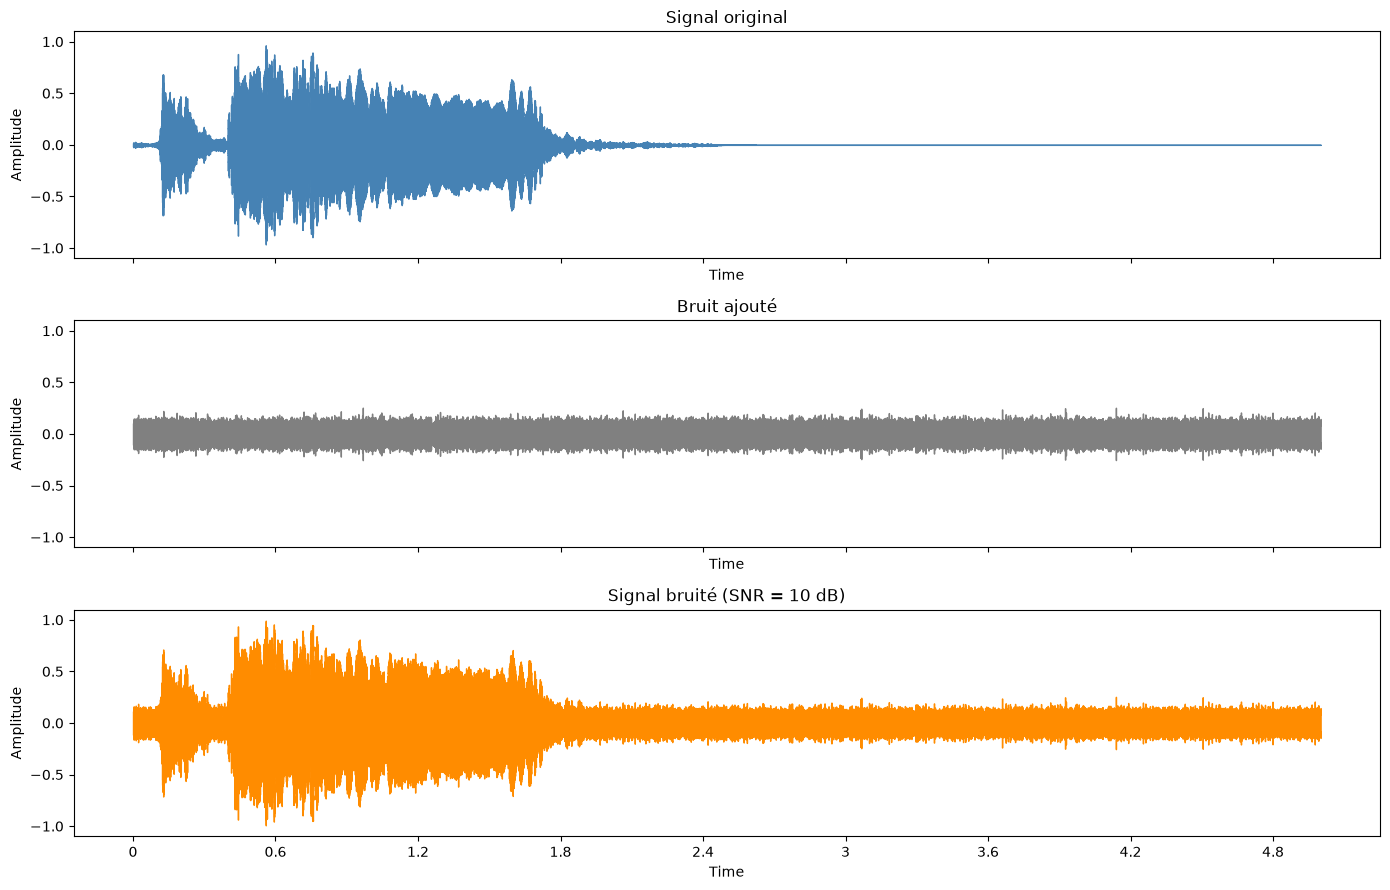

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
librosa.display.waveshow(y, sr=sr, ax=axes[0], color="steelblue")
axes[0].set_title("Signal original")
librosa.display.waveshow(noise, sr=sr, ax=axes[1], color="gray")
axes[1].set_title("Bruit ajouté")
librosa.display.waveshow(y_noisy, sr=sr, ax=axes[2], color="darkorange")
axes[2].set_title("Signal bruité (SNR = 10 dB)")
for ax in axes:
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

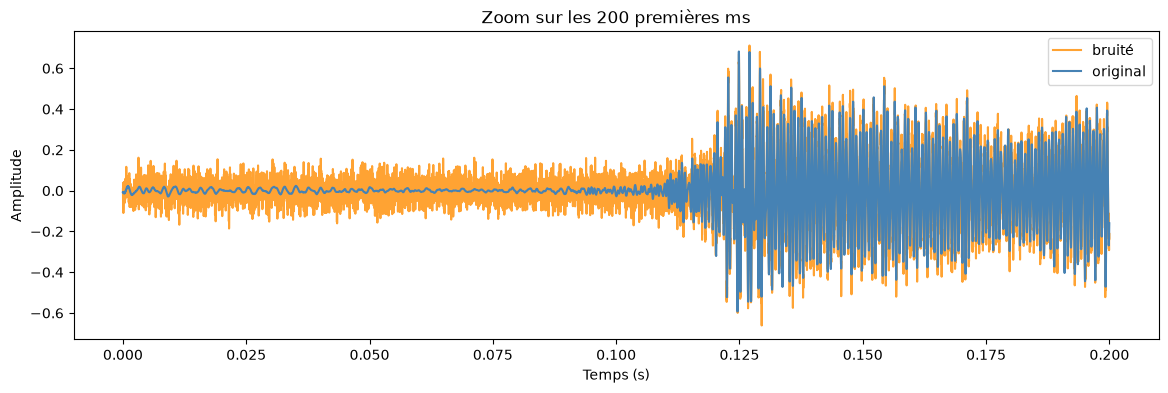

In [14]:
# Zoom sur les 200 premières ms : zone calme (jusqu'à 0,11 s) puis début du chant
seg = slice(0, int(0.2 * sr))
t = np.arange(len(y))[seg] / sr
plt.figure(figsize=(14, 4))
plt.plot(t, y_noisy[seg], color="darkorange", alpha=0.8, label="bruité")
plt.plot(t, y[seg], color="steelblue", label="original")
plt.title("Zoom sur les 200 premières ms")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### Comparaison des spectrogrammes

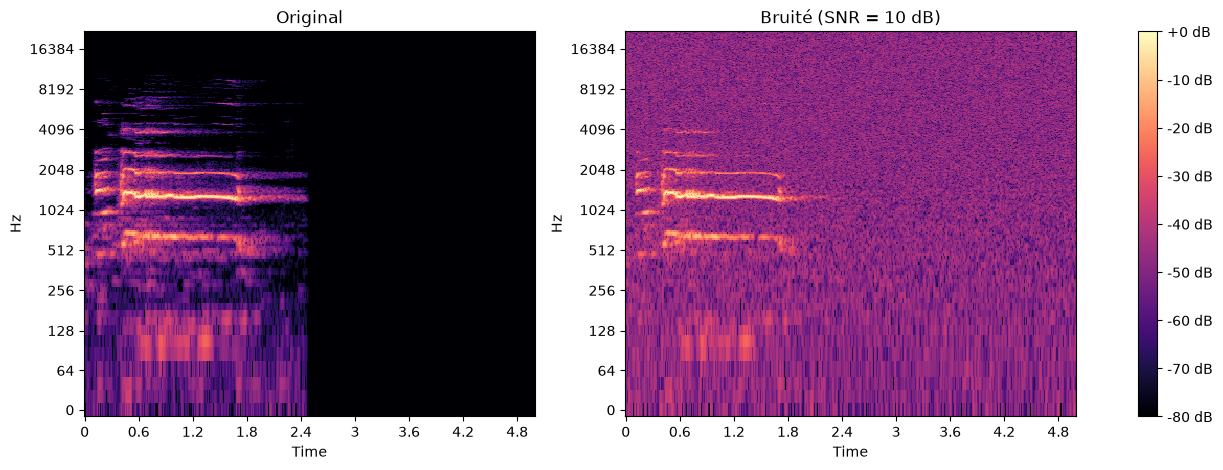

In [15]:
def spec_db(signal):
    return librosa.amplitude_to_db(np.abs(librosa.stft(signal, n_fft=N_FFT, hop_length=HOP)), ref=np.max(np.abs(D)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, sig, title in [(axes[0], y, "Original"), (axes[1], y_noisy, "Bruité (SNR = 10 dB)")]:
    img = librosa.display.specshow(spec_db(sig), sr=sr, hop_length=HOP, x_axis="time", y_axis="log",
                                   ax=ax, vmin=-80, vmax=0)
    ax.set_title(title)
fig.colorbar(img, ax=axes, format="%+2.0f dB")
plt.show()

Les deux spectrogrammes utilisent la **même référence** (le maximum de l'original) et la même échelle de couleurs (-80 à 0 dB) : la comparaison est donc directe.

### Écoute

In [16]:
print("Original")
display(Audio(data=y, rate=sr))
print("Bruité (SNR = 10 dB)")
display(Audio(data=y_noisy, rate=sr))

Original


Bruité (SNR = 10 dB)


### Influence du niveau de bruit

SNR = 20 dB


SNR = 10 dB


SNR = 0 dB


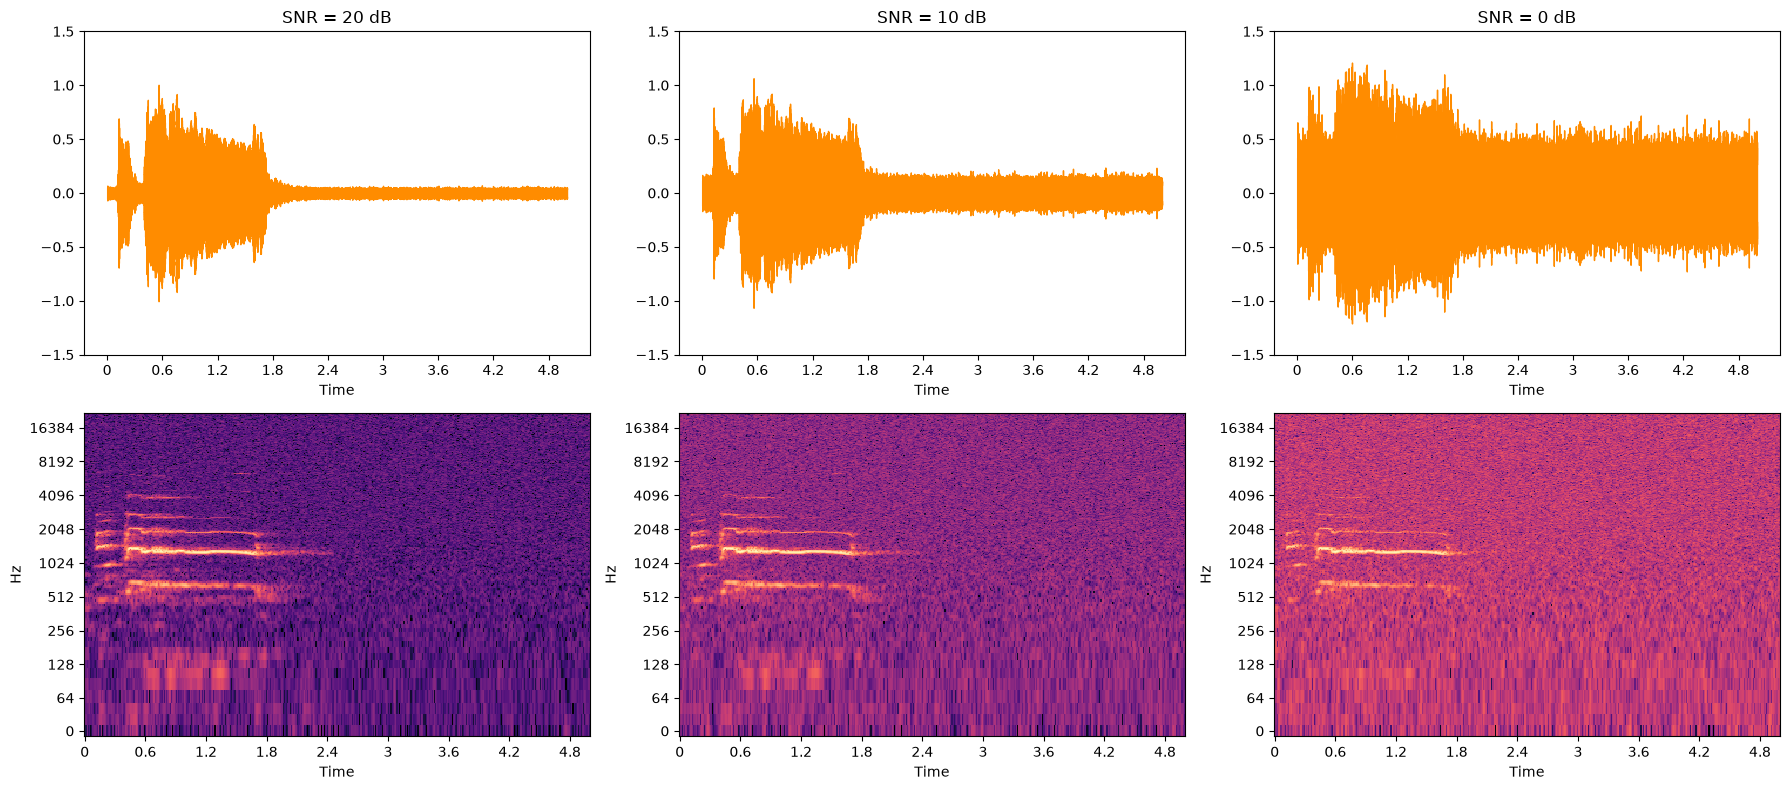

In [17]:
levels = [20, 10, 0]
fig, axes = plt.subplots(2, len(levels), figsize=(18, 8))
for j, level in enumerate(levels):
    yn, _ = add_noise(y, level)
    librosa.display.waveshow(yn, sr=sr, ax=axes[0, j], color="darkorange")
    axes[0, j].set_ylim(-1.5, 1.5)
    axes[0, j].set_title(f"SNR = {level} dB")
    librosa.display.specshow(spec_db(yn), sr=sr, hop_length=HOP, x_axis="time", y_axis="log",
                             ax=axes[1, j], vmin=-80, vmax=0)
    print(f"SNR = {level} dB")
    display(Audio(data=yn, rate=sr))
plt.tight_layout()
plt.show()

### Analyse

| Représentation | Signal original | Signal bruité |
|---|---|---|
| **Waveform** | Chant bien délimité, silence parfait après 2,5 s | Une « bande » de bruit épaissit tout le signal ; le silence final est remplacé par du bruit. L'amplitude maximale augmente |
| **Spectrogramme** | Fond noir, harmoniques nettes | Le fond s'éclaircit sur **toutes les fréquences** et à **tous les instants**, y compris dans le silence final : le bruit blanc a la même énergie moyenne à toutes les fréquences |
| **Écoute** | Chant net | Souffle continu (« chhhh ») superposé au chant |

**Conclusions :**
- Le bruit touche surtout les **zones de faible énergie** : silences et harmoniques aiguës, qui sont les premières masquées. Les harmoniques les plus fortes du chant restent visibles tant que le SNR est suffisant.
- Quand le SNR baisse (20 → 10 → 0 dB), le signal utile se noie progressivement ; à 0 dB, seules la fondamentale et l'harmonique à 1,3 kHz émergent encore.
- À 0 dB, l'amplitude dépasse ±1 : enregistré tel quel dans un fichier audio, le signal serait **écrêté** (saturation). `IPython.display.Audio` normalise le volume par défaut, ce qui masque ce problème à l'écoute.
- Le **spectrogramme** permet de mieux distinguer signal et bruit que le waveform : le chant est concentré sur quelques fréquences, alors que le bruit est étalé partout. C'est le principe des méthodes de **débruitage** par filtrage fréquentiel.
- En apprentissage automatique, on ajoute volontairement du bruit aux données d'entraînement (**data augmentation**) pour rendre un modèle robuste aux enregistrements réels, qui ne sont jamais parfaitement propres.

---
## Conclusion

| Notion | À retenir |
|---|---|
| Chargement | `librosa.load(path, sr=None)` renvoie le signal `y` (1D, entre -1 et 1) et la fréquence `sr` |
| Durée | `len(y) / sr` |
| Waveform | amplitude en fonction du temps : `librosa.display.waveshow` |
| Spectrogramme | STFT + décibels : fréquences en fonction du temps ; Mel pour imiter l'oreille |
| Lecture | `IPython.display.Audio(data=y, rate=sr)` ; un mauvais `rate` change vitesse et hauteur |
| Bruit | bruit blanc gaussien réglé par le SNR ; il se répartit sur toutes les fréquences |